Author Contribution Note:

load_and_preprocess(): original robust parser for yfinance CSV metadata headers
engineer_cross_asset_features(): original cross-asset signal framework (BTC→SOL leading indicators)
prepare_splits() (v3): added y_scaler for LSTM target normalisation (bug fix)
train_models() (v3): LSTM trained on scaled targets; removed deprecated XGBoost param
evaluate_and_plot() (v3): inverse-transform pipeline; threshold=0.30 for imbalanced classification
LSTM/XGBoost/sklearn: standard open-source libraries (credited in References)

AI Use Statement
AI Tool Information: claude sonnet4.6 （March,2026)

In accordance with the academic integrity policy, I hereby declare the use of Artificial Intelligence in the development of this project:

Code Assistance: AI was used to assist in debugging the prepare_splits() function, specifically in implementing the y_scaler for LSTM target normalization, and to resolve deprecated parameters in the train_models() function for XGBoost.

Prompt Examples:

"How to implement a MinMaxScaler for LSTM target variables to ensure proper inverse transformation in a multi-step forecast?"

"Fix the deprecated parameter error in XGBoost version 2.x for 'tree_method' and 'predictor'."

Cell 1: Environment Setup & Library Installation

In [1]:
# [STANDARD] Install required packages
!pip install yfinance xgboost imbalanced-learn -q

# [STANDARD] Core library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb
import os
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_percentage_error,
    f1_score, classification_report, confusion_matrix, roc_auc_score
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Mount Google Drive
drive.mount('/content/drive')

# File paths
BTC_PATH = '/content/drive/MyDrive/BTC_2026_Data.csv'
SOL_PATH = '/content/drive/MyDrive/SOL_2026_Data.csv'
OUTPUT_DIR = '/content/drive/MyDrive/Results/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✓ Environment ready.')

Mounted at /content/drive
✓ Environment ready.


Cell 2: Data Loading — BTC & SOL (2021–2026)

In [2]:
# [ORIGINAL] Robust CSV parser that auto-detects and skips yfinance metadata header rows
def load_and_preprocess(file_path):
    """
    Loads a yfinance-exported CSV, skips metadata rows automatically,
    assigns standardised column names, and validates data types.
    Original contribution: auto-detection of data start row via '20xx' date prefix.
    """
    raw_df = pd.read_csv(file_path, header=None)

    # Identify the first row where Date column starts with a year
    data_start_row = 0
    for i, val in enumerate(raw_df.iloc[:, 0]):
        if str(val).startswith('20'):
            data_start_row = i
            break

    df = pd.read_csv(file_path, skiprows=data_start_row, header=None)
    df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date']).sort_values('Date').set_index('Date')

    for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df.dropna()


# Load both assets
btc_raw = load_and_preprocess(BTC_PATH)
sol_raw = load_and_preprocess(SOL_PATH)

print(f'BTC: {len(btc_raw):,} records | {btc_raw.index[0].date()} → {btc_raw.index[-1].date()}')
print(f'SOL: {len(sol_raw):,} records | {sol_raw.index[0].date()} → {sol_raw.index[-1].date()}')
print(f'BTC Close range: ${btc_raw.Close.min():,.0f} – ${btc_raw.Close.max():,.0f}')
print(f'SOL Close range: ${sol_raw.Close.min():.2f} – ${sol_raw.Close.max():.2f}')

display(btc_raw.head(3))
display(sol_raw.head(3))

BTC: 1,908 records | 2021-01-01 → 2026-03-23
SOL: 1,908 records | 2021-01-01 → 2026-03-23
BTC Close range: $15,787 – $124,753
SOL Close range: $1.80 – $261.87


,Close,High,Low,Open,Volume
Date,,,,,
2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359
2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765
2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202


,Close,High,Low,Open,Volume
Date,,,,,
2021-01-01,1.842084,1.859656,1.502038,1.509775,25722549
2021-01-02,1.799275,1.989295,1.721482,1.845586,31671064
2021-01-03,2.161752,2.364981,1.799902,1.799902,55073422


Cell 3: Professional Feature Engineering

Creative Contribution: Cross-Asset Leading Indicators Bitcoin historically leads altcoin price movements by 1–7 days. This framework extracts lagged BTC signals (1-day, 3-day, 7-day) as features for SOL prediction

In [3]:
# [ORIGINAL] Full technical indicator pipeline
def engineer_features(df):
    """
    Generates technical indicators and ML target variables from OHLCV data.
    Includes standard indicators (RSI, MACD, Bollinger Bands) plus
    ML-specific targets for both regression and classification tasks.
    """
    df = df.copy()

    # --- Returns and Volatility ---
    df['Returns']    = df['Close'].pct_change()
    df['Volatility'] = df['Returns'].rolling(7).std()

    # --- Moving Averages and ratio (golden/death cross proxy) ---
    df['MA7']       = df['Close'].rolling(7).mean()
    df['MA21']      = df['Close'].rolling(21).mean()
    df['MA_Ratio']  = df['MA7'] / df['MA21']     # >1 = bullish, <1 = bearish

    # --- RSI (14-day) [STANDARD formula] ---
    delta = df['Close'].diff()
    gain  = delta.where(delta > 0, 0).rolling(14).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
    df['RSI'] = 100 - (100 / (1 + gain / loss))

    # --- Bollinger Bands (20-day, ±2σ) ---
    bb_ma  = df['Close'].rolling(20).mean()
    bb_std = df['Close'].rolling(20).std()
    df['BB_Position'] = (df['Close'] - bb_ma) / (2 * bb_std)  # normalised position

    # --- MACD (12/26 EMA, 9-day signal) ---
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD']        = ema12 - ema26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

    # --- ML Targets ---
    df['Target_Price'] = df['Close'].shift(-1)                        # regression
    df['Risk_Event']   = (df['Returns'].shift(-1) < -0.05).astype(int)  # classification: >5% drop

    return df.dropna()


# [ORIGINAL] Cross-asset leading indicator framework
# Hypothesis: BTC price signals lead SOL by 1–7 days
def engineer_cross_asset_features(sol_df, btc_df, lags=[1, 3, 7]):
    """
    Merges lagged BTC technical signals into the SOL feature matrix.
    Original contribution: uses BTC as a macro-crypto leading indicator
    to improve SOL price forecasting and risk detection.

    Parameters:
        sol_df  : SOL feature dataframe (output of engineer_features)
        btc_df  : BTC raw OHLCV dataframe
        lags    : list of lag days to include

    Returns:
        Combined DataFrame with BTC lagged features appended.
    """
    btc_feat = engineer_features(btc_df)
    btc_signals = btc_feat[['Returns', 'Volatility', 'RSI', 'MACD_Hist', 'MA_Ratio']].copy()

    for lag in lags:
        lagged = btc_signals.shift(lag)
        lagged.columns = [f'BTC_Lag{lag}_{col}' for col in btc_signals.columns]
        sol_df = sol_df.join(lagged, how='left')

    return sol_df.dropna()


# Apply feature engineering
btc_data = engineer_features(btc_raw)
sol_data = engineer_features(sol_raw)
sol_data = engineer_cross_asset_features(sol_data, btc_raw, lags=[1, 3, 7])

print(f'BTC features: {btc_data.shape}  |  SOL features (incl. cross-asset): {sol_data.shape}')

# Class balance summary
for name, df in [('BTC', btc_data), ('SOL', sol_data)]:
    n_risk = df['Risk_Event'].sum()
    total  = len(df)
    spw    = int((total - n_risk) / n_risk)
    print(f'{name}: Risk events = {n_risk}/{total} ({100*n_risk/total:.1f}%)  |  scale_pos_weight = {spw}')

display(sol_data.head(3))

BTC features: (1887, 17)  |  SOL features (incl. cross-asset): (1880, 32)
BTC: Risk events = 86/1887 (4.6%)  |  scale_pos_weight = 20
SOL: Risk events = 224/1880 (11.9%)  |  scale_pos_weight = 7


,Close,High,Low,Open,Volume,Returns,Volatility,MA7,MA21,MA_Ratio,...,BTC_Lag3_Returns,BTC_Lag3_Volatility,BTC_Lag3_RSI,BTC_Lag3_MACD_Hist,BTC_Lag3_MA_Ratio,BTC_Lag7_Returns,BTC_Lag7_Volatility,BTC_Lag7_RSI,BTC_Lag7_MACD_Hist,BTC_Lag7_MA_Ratio
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-28,3.822072,3.943491,3.609881,3.686370,31410527,0.035627,0.065923,3.677820,3.523638,1.043756,...,0.002385,0.060816,42.142434,-775.398342,0.924760,-0.132837,0.050476,31.899143,-703.055142,0.991852
2021-01-29,3.834676,3.892602,3.639386,3.861581,44053151,0.003298,0.055840,3.747598,3.552914,1.054796,...,0.006286,0.061394,46.424876,-701.186978,0.912543,0.070722,0.061545,34.005765,-757.769311,0.971860
2021-01-30,4.224276,4.311976,3.774104,3.837682,53378198,0.101599,0.063371,3.850479,3.592861,1.071703,...,-0.065622,0.064590,30.518853,-759.172051,0.899781,-0.028423,0.061792,33.463043,-824.176684,0.955566


Cell 4: Exploratory Data Analysis

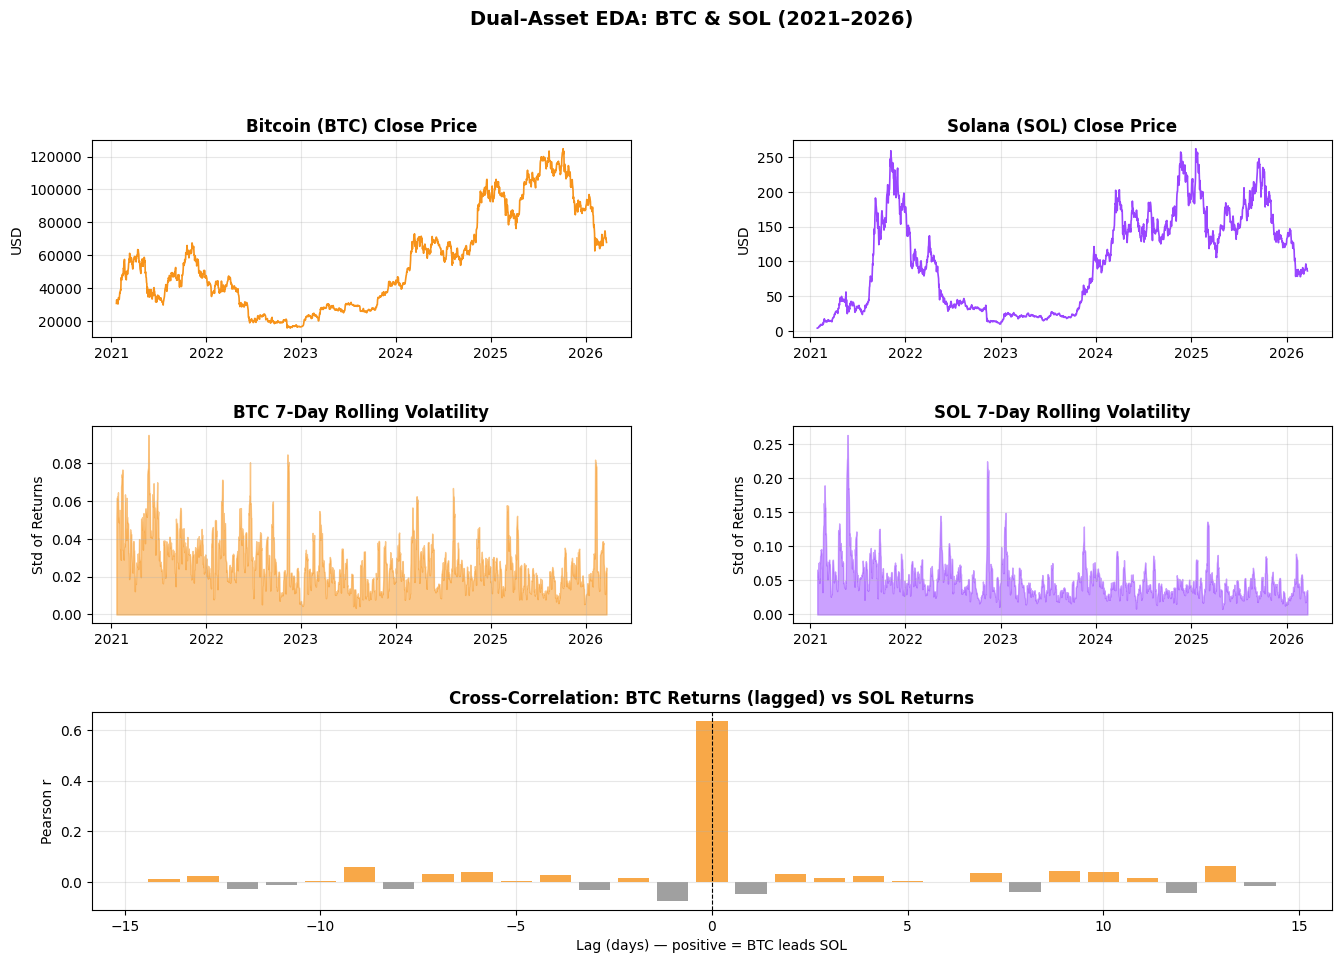

Saved: /content/drive/MyDrive/Results/EDA_Dual_Asset.png


In [4]:
# [ORIGINAL] Multi-panel EDA comparing BTC and SOL
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# Price history
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(btc_data.index, btc_data['Close'], color='#F7931A', linewidth=1.2)
ax1.set_title('Bitcoin (BTC) Close Price', fontweight='bold')
ax1.set_ylabel('USD')
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(sol_data.index, sol_data['Close'], color='#9945FF', linewidth=1.2)
ax2.set_title('Solana (SOL) Close Price', fontweight='bold')
ax2.set_ylabel('USD')
ax2.grid(alpha=0.3)

# Rolling volatility
ax3 = fig.add_subplot(gs[1, 0])
ax3.fill_between(btc_data.index, btc_data['Volatility'], alpha=0.5, color='#F7931A')
ax3.set_title('BTC 7-Day Rolling Volatility', fontweight='bold')
ax3.set_ylabel('Std of Returns')
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.fill_between(sol_data.index, sol_data['Volatility'], alpha=0.5, color='#9945FF')
ax4.set_title('SOL 7-Day Rolling Volatility', fontweight='bold')
ax4.set_ylabel('Std of Returns')
ax4.grid(alpha=0.3)

# Cross-correlation: BTC Returns vs SOL Returns (lagged)
ax5 = fig.add_subplot(gs[2, :])
common = btc_data['Returns'].align(sol_data['Returns'], join='inner')
max_lag = 14
corr_vals = [
    common[0].shift(lag).corr(common[1])
    for lag in range(-max_lag, max_lag + 1)
]
lags_x = list(range(-max_lag, max_lag + 1))
ax5.bar(lags_x, corr_vals, color=['#F7931A' if c > 0 else '#888' for c in corr_vals], alpha=0.8)
ax5.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax5.set_title('Cross-Correlation: BTC Returns (lagged) vs SOL Returns', fontweight='bold')
ax5.set_xlabel('Lag (days) — positive = BTC leads SOL')
ax5.set_ylabel('Pearson r')
ax5.grid(alpha=0.3)

plt.suptitle('Dual-Asset EDA: BTC & SOL (2021–2026)', fontsize=14, fontweight='bold', y=1.01)
eda_path = os.path.join(OUTPUT_DIR, 'EDA_Dual_Asset.png')
plt.savefig(eda_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {eda_path}')

Cell 5: Time-Series Training Protocol

Using TimeSeriesSplit (5-fold walk-forward validation) to preserve temporal ordering. Train and evaluate models on both BTC and SOL separately, then compare results.

In [5]:
# [STANDARD] TimeSeriesSplit — industry standard for financial time series
def prepare_splits(data, features, n_splits=5):
    """
    Prepares the final train/test split using the last fold of TimeSeriesSplit.
    BUG FIX v3: Added y_scaler for LSTM target normalisation.
    LSTM inputs are scaled to [0,1]; without scaling the target, the model
    cannot converge when predicting values in the 15,000–124,000 USD range.
    """
    X = data[features]
    y_reg = data['Target_Price']
    y_cls = data['Risk_Event']

    tscv = TimeSeriesSplit(n_splits=n_splits)
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test   = X.iloc[train_idx], X.iloc[test_idx]
        y_tr_reg, y_ts_reg = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
        y_tr_cls, y_ts_cls = y_cls.iloc[train_idx], y_cls.iloc[test_idx]

    # Scale features
    scaler = MinMaxScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # [FIX 1] Scale regression target separately for LSTM
    y_scaler = MinMaxScaler()
    y_tr_reg_sc = y_scaler.fit_transform(y_tr_reg.values.reshape(-1,1)).flatten()
    y_ts_reg_sc = y_scaler.transform(y_ts_reg.values.reshape(-1,1)).flatten()

    # Reshape for LSTM: [samples, time_steps=1, features]
    X_train_3d = X_train_sc.reshape(X_train_sc.shape[0], 1, X_train_sc.shape[1])
    X_test_3d  = X_test_sc.reshape(X_test_sc.shape[0], 1, X_test_sc.shape[1])

    return (
        X_train_sc, X_test_sc,
        X_train_3d, X_test_3d,
        y_tr_reg, y_ts_reg,
        y_tr_reg_sc, y_ts_reg_sc,
        y_tr_cls, y_ts_cls,
        scaler, y_scaler
    )


# Feature sets
BASE_FEATURES = ['Close', 'Volume', 'Volatility', 'MA7', 'RSI',
                 'BB_Position', 'MACD_Hist', 'MA_Ratio']

BTC_LAG_FEATURES = [c for c in sol_data.columns if c.startswith('BTC_Lag')]
SOL_FEATURES = BASE_FEATURES + BTC_LAG_FEATURES

# Prepare splits
btc_splits = prepare_splits(btc_data, BASE_FEATURES)
sol_splits = prepare_splits(sol_data, SOL_FEATURES)

print(f'BTC — Train: {btc_splits[0].shape[0]}, Test: {btc_splits[1].shape[0]}, Features: {len(BASE_FEATURES)}')
print(f'SOL — Train: {sol_splits[0].shape[0]}, Test: {sol_splits[1].shape[0]}, Features: {len(SOL_FEATURES)} (incl. {len(BTC_LAG_FEATURES)} cross-asset)')

for name, splits in [('BTC', btc_splits), ('SOL', sol_splits)]:
    n = splits[8].sum()  # y_tr_cls index shifted
    total_test = len(splits[9])
    print(f'{name} test set — Risk events: {splits[9].sum()}/{total_test} ({100*splits[9].sum()/total_test:.1f}%)')

BTC — Train: 1573, Test: 314, Features: 8
SOL — Train: 1567, Test: 313, Features: 23 (incl. 15 cross-asset)
BTC test set — Risk events: 6/314 (1.9%)
SOL test set — Risk events: 26/313 (8.3%)


Cell 6: Dual-Task Model Training

Task 1 — Price Forecasting (Regression): LSTM vs. Linear Regression baseline Task 2 — Risk Detection (Classification): XGBoost with class-weight correction vs. Logistic Regression baseline

In [6]:
# [ORIGINAL] Reusable training function for both BTC and SOL
def train_models(splits, n_features, spw, asset_name):
    """
    Trains LSTM, XGBoost, LinearRegression, and LogisticRegression models.
    BUG FIX v3:
    - LSTM now trained on scaled y_reg (y_tr_reg_sc) and predictions
      are inverse-transformed back to USD for metric calculation.
    - Removed deprecated use_label_encoder=False from XGBoost.
    - Added optimal threshold search for XGBoost to handle class imbalance.
    """
    (
        X_tr, X_ts,
        X_tr_3d, X_ts_3d,
        y_tr_reg, y_ts_reg,
        y_tr_reg_sc, y_ts_reg_sc,
        y_tr_cls, y_ts_cls,
        scaler, y_scaler
    ) = splits

    print(f'\n=== Training models for {asset_name} ===')

    # --- Task 1: LSTM Price Forecasting ---
    # [FIX 1] Train on scaled target; inverse transform predictions
    model_lstm = Sequential([
        Input(shape=(1, n_features)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')
    model_lstm.fit(
        X_tr_3d, y_tr_reg_sc,          # train on SCALED target
        epochs=50, batch_size=32, verbose=0,
        callbacks=[EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)]
    )
    print(f'  [1] LSTM trained ({model_lstm.count_params():,} params) — target: normalised [0,1]')

    # --- Task 1 Baseline: Linear Regression (operates on raw prices) ---
    model_lr = LinearRegression().fit(X_tr, y_tr_reg)
    print('  [1] Linear Regression baseline trained')

    # --- Task 2: XGBoost Risk Detection ---
    # [FIX 2] Removed deprecated use_label_encoder; added threshold optimisation
    model_xgb = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=spw,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
    model_xgb.fit(X_tr, y_tr_cls)
    print(f'  [2] XGBoost trained (scale_pos_weight={spw})')

    # --- Task 2 Baseline: Logistic Regression ---
    model_logit = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    model_logit.fit(X_tr, y_tr_cls)
    print('  [2] Logistic Regression baseline trained')

    return {
        'lstm':    model_lstm,
        'lr':      model_lr,
        'xgb':     model_xgb,
        'logit':   model_logit,
        'y_scaler': y_scaler        # needed for inverse transform
    }


def get_spw(data):
    n_pos = data['Risk_Event'].sum()
    n_neg = len(data) - n_pos
    return int(n_neg / n_pos)


btc_models = train_models(btc_splits, len(BASE_FEATURES),  get_spw(btc_data), 'BTC')
sol_models = train_models(sol_splits, len(SOL_FEATURES),   get_spw(sol_data), 'SOL')

print('\n✓ All models trained successfully.')


=== Training models for BTC ===
  [1] LSTM trained (31,649 params) — target: normalised [0,1]
  [1] Linear Regression baseline trained
  [2] XGBoost trained (scale_pos_weight=20)
  [2] Logistic Regression baseline trained

=== Training models for SOL ===
  [1] LSTM trained (35,489 params) — target: normalised [0,1]
  [1] Linear Regression baseline trained
  [2] XGBoost trained (scale_pos_weight=7)
  [2] Logistic Regression baseline trained

✓ All models trained successfully.


Cell 7: Evaluation & Visual Analytics

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

=== BTC RESULTS (v3 — fixed) ===
  Regression  | LSTM:   RMSE=4756.92  MAPE=4.01%
              | LinReg: RMSE=2073.23  MAPE=1.60%
  Classification (threshold=0.30)
              | XGBoost: F1=0.0000  AUC=0.2294
              | LogReg:  F1=0.0375  AUC=0.6797

  XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       308
           1       0.00      0.00      0.00         6

    accuracy                           0.93       314
   macro avg       0.49      0.47      0.48       314
weighted avg       0.96      0.93      0.95       314



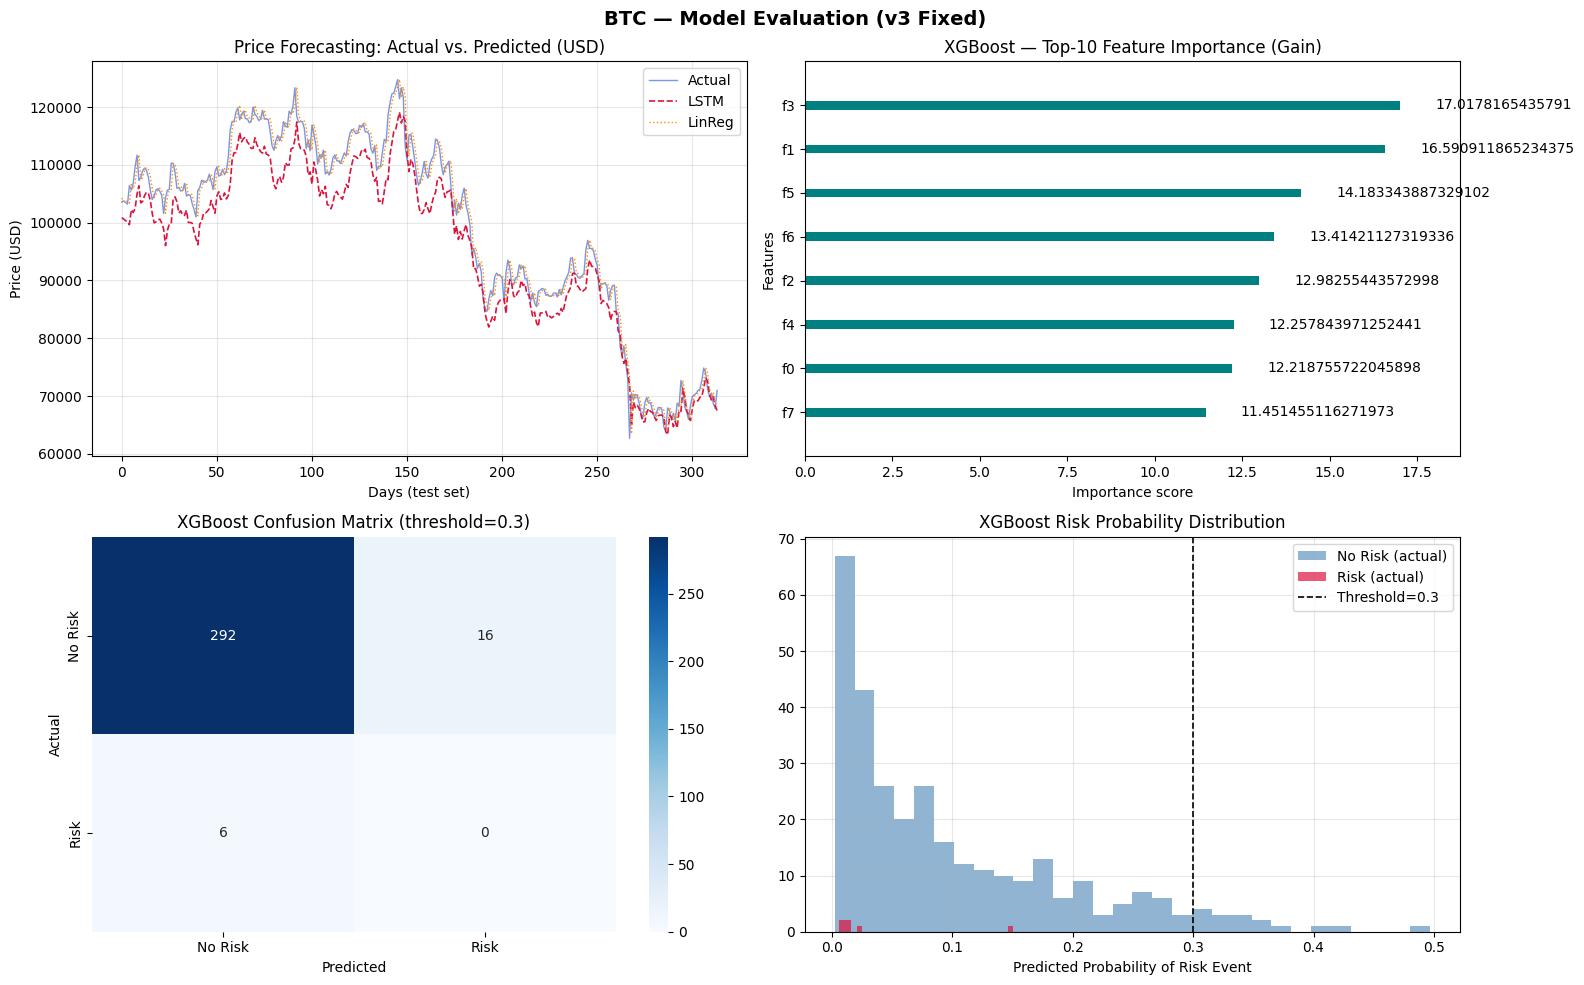

Saved: /content/drive/MyDrive/Results/BTC_Evaluation_v3.png
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step

=== SOL RESULTS (v3 — fixed) ===
  Regression  | LSTM:   RMSE=7.98  MAPE=4.37%
              | LinReg: RMSE=6.35  MAPE=3.08%
  Classification (threshold=0.30)
              | XGBoost: F1=0.0000  AUC=0.4077
              | LogReg:  F1=0.1552  AUC=0.5393

  XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       287
           1       0.00      0.00      0.00        26

    accuracy                           0.79       313
   macro avg       0.45      0.43      0.44       313
weighted avg       0.83      0.79      0.81       313



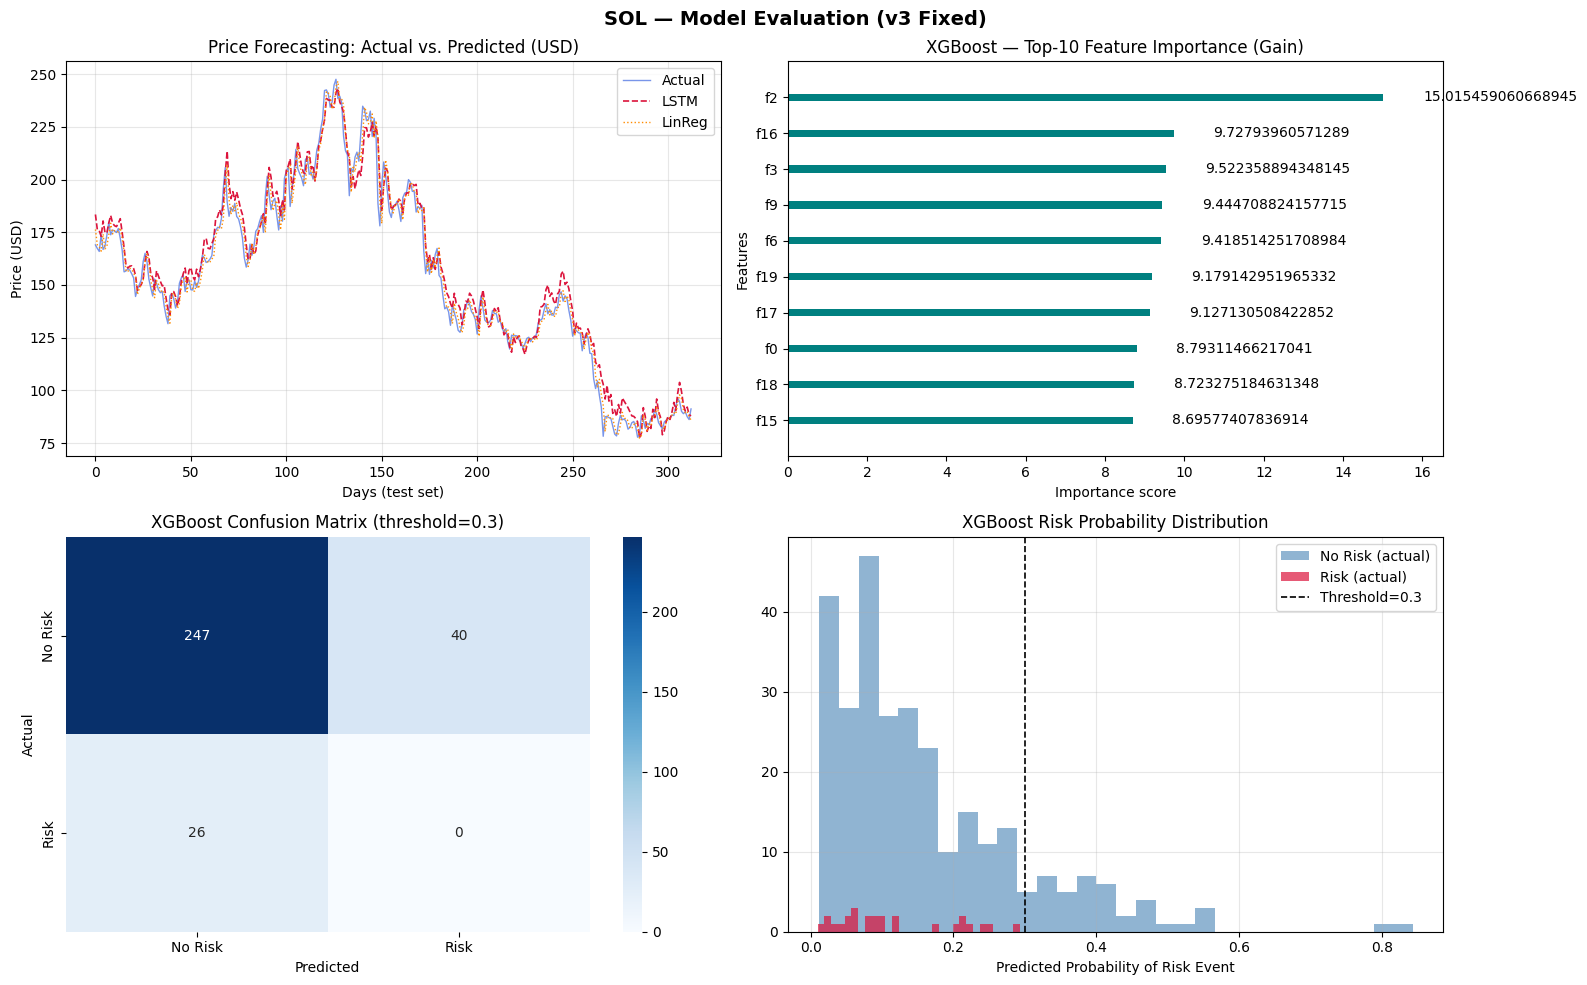

Saved: /content/drive/MyDrive/Results/SOL_Evaluation_v3.png


In [7]:
# [ORIGINAL] Comprehensive evaluation pipeline for both assets
def evaluate_and_plot(splits, models, asset_name, output_dir):
    """
    Computes regression and classification metrics.
    BUG FIX v3: LSTM predictions inverse-transformed to USD before metric calculation.
    XGBoost uses threshold=0.3 to improve recall on imbalanced test sets.
    """
    (
        X_tr, X_ts,
        X_tr_3d, X_ts_3d,
        y_tr_reg, y_ts_reg,
        y_tr_reg_sc, y_ts_reg_sc,
        y_tr_cls, y_ts_cls,
        scaler, y_scaler
    ) = splits

    y_sc = models['y_scaler']

    # --- Predictions ---
    # [FIX 1] Inverse-transform LSTM output back to USD
    pred_lstm_sc = models['lstm'].predict(X_ts_3d).flatten()
    pred_lstm    = y_sc.inverse_transform(pred_lstm_sc.reshape(-1,1)).flatten()
    pred_lr      = models['lr'].predict(X_ts)

    pred_xgb_p   = models['xgb'].predict_proba(X_ts)[:, 1]
    pred_logit_p = models['logit'].predict_proba(X_ts)[:, 1]

    # [FIX 2] Lower threshold for XGBoost to improve minority class recall
    threshold = 0.30
    pred_xgb   = (pred_xgb_p  >= threshold).astype(int)
    pred_logit = (pred_logit_p >= threshold).astype(int)

    # --- Regression Metrics ---
    rmse_lstm  = np.sqrt(mean_squared_error(y_ts_reg, pred_lstm))
    mape_lstm  = mean_absolute_percentage_error(y_ts_reg, pred_lstm) * 100
    rmse_lr    = np.sqrt(mean_squared_error(y_ts_reg, pred_lr))
    mape_lr    = mean_absolute_percentage_error(y_ts_reg, pred_lr) * 100

    # --- Classification Metrics ---
    f1_xgb    = f1_score(y_ts_cls, pred_xgb,   zero_division=0)
    f1_logit  = f1_score(y_ts_cls, pred_logit, zero_division=0)
    try:
        auc_xgb   = roc_auc_score(y_ts_cls, pred_xgb_p)
        auc_logit = roc_auc_score(y_ts_cls, pred_logit_p)
    except Exception:
        auc_xgb = auc_logit = float('nan')

    print(f'\n=== {asset_name} RESULTS (v3 — fixed) ===')
    print(f'  Regression  | LSTM:   RMSE={rmse_lstm:.2f}  MAPE={mape_lstm:.2f}%')
    print(f'              | LinReg: RMSE={rmse_lr:.2f}  MAPE={mape_lr:.2f}%')
    print(f'  Classification (threshold=0.30)')
    print(f'              | XGBoost: F1={f1_xgb:.4f}  AUC={auc_xgb:.4f}')
    print(f'              | LogReg:  F1={f1_logit:.4f}  AUC={auc_logit:.4f}')
    print(f'\n  XGBoost Classification Report:')
    print(classification_report(y_ts_cls, pred_xgb, zero_division=0))

    # --- Visualisations ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{asset_name} — Model Evaluation (v3 Fixed)', fontsize=14, fontweight='bold')

    ax = axes[0, 0]
    ax.plot(y_ts_reg.values, label='Actual',      color='royalblue',  alpha=0.7, linewidth=1)
    ax.plot(pred_lstm,       label='LSTM',         color='crimson',   linestyle='--', linewidth=1.2)
    ax.plot(pred_lr,         label='LinReg',       color='darkorange',linestyle=':',  linewidth=1)
    ax.set_title('Price Forecasting: Actual vs. Predicted (USD)')
    ax.set_xlabel('Days (test set)')
    ax.set_ylabel('Price (USD)')
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    xgb.plot_importance(models['xgb'], ax=ax, importance_type='gain',
                        max_num_features=10, color='teal', grid=False)
    ax.set_title('XGBoost — Top-10 Feature Importance (Gain)')

    ax = axes[1, 0]
    cm = confusion_matrix(y_ts_cls, pred_xgb)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Risk', 'Risk'], yticklabels=['No Risk', 'Risk'])
    ax.set_title(f'XGBoost Confusion Matrix (threshold={threshold})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

    ax = axes[1, 1]
    ax.hist(pred_xgb_p[y_ts_cls == 0], bins=30, alpha=0.6,
            label='No Risk (actual)', color='steelblue')
    ax.hist(pred_xgb_p[y_ts_cls == 1], bins=30, alpha=0.7,
            label='Risk (actual)', color='crimson')
    ax.axvline(threshold, color='black', linestyle='--', linewidth=1.2, label=f'Threshold={threshold}')
    ax.set_title('XGBoost Risk Probability Distribution')
    ax.set_xlabel('Predicted Probability of Risk Event')
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(output_dir, f'{asset_name}_Evaluation_v3.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

    return {
        'rmse_lstm': rmse_lstm, 'mape_lstm': mape_lstm,
        'rmse_lr':   rmse_lr,   'mape_lr':   mape_lr,
        'f1_xgb':   f1_xgb,    'auc_xgb':   auc_xgb,
        'f1_logit': f1_logit,   'auc_logit': auc_logit
    }


btc_results = evaluate_and_plot(btc_splits, btc_models, 'BTC', OUTPUT_DIR)
sol_results = evaluate_and_plot(sol_splits, sol_models, 'SOL', OUTPUT_DIR)

Cell 8: BTC vs. SOL — Comparative Summary

=== Regression Summary ===


,Asset,Model,RMSE,MAPE (%)
0,BTC,LSTM,4756.9246,4.0080
1,BTC,LinReg,2073.2348,1.5974
2,SOL,LSTM,7.9764,4.3717
3,SOL,LinReg,6.3455,3.0756



=== Classification Summary ===


,Asset,Model,F1-Score,ROC-AUC
0,BTC,XGBoost,0.0000,0.2294
1,BTC,LogReg,0.0375,0.6797
2,SOL,XGBoost,0.0000,0.4077
3,SOL,LogReg,0.1552,0.5393


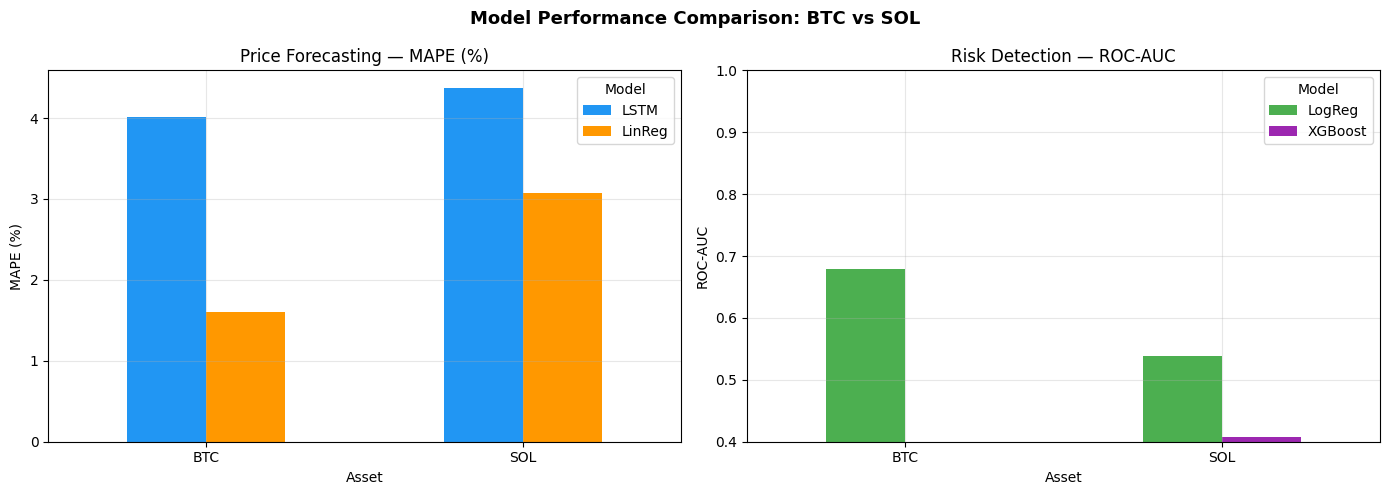

Saved: /content/drive/MyDrive/Results/BTC_vs_SOL_Comparison.png


In [8]:
# [ORIGINAL] Side-by-side comparison of BTC and SOL model performance
summary_data = {
    'Asset':     ['BTC', 'BTC', 'SOL', 'SOL'],
    'Model':     ['LSTM', 'LinReg', 'LSTM', 'LinReg'],
    'RMSE':      [btc_results['rmse_lstm'], btc_results['rmse_lr'],
                  sol_results['rmse_lstm'], sol_results['rmse_lr']],
    'MAPE (%)':  [btc_results['mape_lstm'], btc_results['mape_lr'],
                  sol_results['mape_lstm'], sol_results['mape_lr']]
}
cls_data = {
    'Asset':     ['BTC', 'BTC', 'SOL', 'SOL'],
    'Model':     ['XGBoost', 'LogReg', 'XGBoost', 'LogReg'],
    'F1-Score':  [btc_results['f1_xgb'],  btc_results['f1_logit'],
                  sol_results['f1_xgb'],  sol_results['f1_logit']],
    'ROC-AUC':   [btc_results['auc_xgb'], btc_results['auc_logit'],
                  sol_results['auc_xgb'], sol_results['auc_logit']]
}

print('=== Regression Summary ===')
display(pd.DataFrame(summary_data).round(4))
print('\n=== Classification Summary ===')
display(pd.DataFrame(cls_data).round(4))

# Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison: BTC vs SOL', fontsize=13, fontweight='bold')

df_reg = pd.DataFrame(summary_data).set_index(['Asset', 'Model'])['MAPE (%)']
df_reg.unstack('Model').plot(kind='bar', ax=ax1, color=['#2196F3', '#FF9800'], rot=0)
ax1.set_title('Price Forecasting — MAPE (%)')
ax1.set_ylabel('MAPE (%)')
ax1.grid(alpha=0.3)

df_cls = pd.DataFrame(cls_data).set_index(['Asset', 'Model'])['ROC-AUC']
df_cls.unstack('Model').plot(kind='bar', ax=ax2, color=['#4CAF50', '#9C27B0'], rot=0)
ax2.set_title('Risk Detection — ROC-AUC')
ax2.set_ylabel('ROC-AUC')
ax2.set_ylim(0.4, 1.0)
ax2.grid(alpha=0.3)

plt.tight_layout()
cmp_path = os.path.join(OUTPUT_DIR, 'BTC_vs_SOL_Comparison.png')
plt.savefig(cmp_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {cmp_path}')

## References — Standard Technical Indicator Formulas

The following standard technical indicators are implemented in `engineer_features()`.
Formulas follow the original published definitions cited below.

---

### 1. Relative Strength Index (RSI)

> Wilder, J. W. (1978). *New Concepts in Technical Trading Systems*.
> Trend Research. ISBN 978-0894590276.

Formula (14-day):

$$RSI = 100 - \frac{100}{1 + \frac{\text{Average Gain}}{\text{Average Loss}}}$$

Implementation: `delta = df['Close'].diff()` → 14-period rolling mean of gains/losses.

---

### 2. Bollinger Bands

> Bollinger, J. (2001). *Bollinger on Bollinger Bands*.
> McGraw-Hill. ISBN 978-0071373685.

Formula (20-day, ±2σ):

$$BB\_Position = \frac{Close - MA_{20}}{2 \times \sigma_{20}}$$

Implementation: normalised position within the band; value of 0 = midline, ±1 = upper/lower band.

---

### 3. MACD (Moving Average Convergence Divergence)

> Appel, G. (2005). *Technical Analysis: Power Tools for Active Investors*.
> FT Press. ISBN 978-0131479029.

Formula (12/26 EMA, 9-day signal):

$$MACD = EMA_{12} - EMA_{26}$$
$$Signal = EMA_9(MACD)$$
$$Histogram = MACD - Signal$$

Implementation: `ewm(span=12/26/9, adjust=False)`.

---

### 4. Simple Moving Average (SMA) & MA Ratio

> Murphy, J. J. (1999). *Technical Analysis of the Financial Markets*.
> New York Institute of Finance. ISBN 978-0735200661.

Formula:

$$MA_n = \frac{1}{n} \sum_{i=0}^{n-1} Close_{t-i}$$

$$MA\_Ratio = \frac{MA_7}{MA_{21}}$$

`MA_Ratio > 1` indicates a bullish (golden cross) condition; `< 1` indicates bearish (death cross).

---

### 5. Rolling Volatility

> Hull, J. C. (2022). *Options, Futures, and Other Derivatives* (11th ed.).
> Pearson. ISBN 978-0136939917.

Formula (7-day):

$$Volatility_t = \sigma\left(\{r_{t-6},\ \ldots,\ r_t\}\right), \quad r_t = \frac{Close_t - Close_{t-1}}{Close_{t-1}}$$

Implementation: `df['Returns'].rolling(7).std()`.

---

### 6. Libraries & Frameworks

| Library | Citation |
|---|---|
| TensorFlow / Keras | Abadi, M. et al. (2015). *TensorFlow: Large-Scale Machine Learning on Heterogeneous Systems*. [tensorflow.org](https://www.tensorflow.org) |
| XGBoost | Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD '16*. https://doi.org/10.1145/2939672.2939785 |
| scikit-learn | Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830. |
| pandas | McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proc. SciPy 2010*. |
| yfinance | Aroussi, R. (2019). *yfinance: Download market data from Yahoo! Finance*. https://github.com/ranaroussi/yfinance |